In [58]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal

### define useful function reading the nominal file 

In [23]:
def savedata(phase,delay,BPD,Ref,fname):
    N=len(phase)
    file=open(fname,"wt")
    file.write(f"phase (degrees), delay (ns), EO Modulated (V), Un Modulatoed/Reference (V)\n")
    for i in range(N):
        file.write(f"{phase[i]}, {delay[i]}, {BPD[i]}, {Ref[i]}\n")
    file.close()

def PostP(npyfile):
    name=npyfile.split('.')[0]
    CoarseScan=np.load(npyfile, allow_pickle=True).item()
    CoarseScan.keys()
    peak=CoarseScan['peak']
    phase=CoarseScan['phase']
    
    N=len(peak)
    BPD=np.zeros(N)
    Ref=np.zeros(N)
    delay=np.zeros(N)
    tperdegree=1e9/81.25e6/360 
    for i in range(N):
        BPD[i]=peak[i][4]
        Ref[i]=peak[i][3]
        delay[i]=(phase[i]-phase[0])*tperdegree
    
    # count how many 0 are repeated in the delay array
    zero_count = 0
    for i in range(1, N):
        if delay[i] == 0:
            zero_count += 1
        else:
            break
    
    if zero_count > 0:
        print(f"Warning: {zero_count} consecutive zeros found in the delay array.")
    
# make a new array that has BPD avearege every four points
    BPD_ave = np.array([np.mean(BPD[i:i+4]) for i in range(0, N, 4)])
    Ref_ave = np.array([np.mean(Ref[i:i+4]) for i in range(0, N, 4)])
    delay_ave = np.array([np.mean(delay[i:i+4]) for i in range(0, N, 4)])
    phase_ave = np.array([np.mean(phase[i:i+4]) for i in range(0, N, 4)])
# same with std deviation
    BPD_std = np.array([np.std(BPD[i:i+4]) for i in range(0, N, 4)])
    Ref_std = np.array([np.std(Ref[i:i+4]) for i in range(0, N, 4)])
    delay_std = np.array([np.std(delay[i:i+4]) for i in range(0, N, 4)])
    phase_std = np.array([np.std(phase[i:i+4]) for i in range(0, N, 4)])
    
    # Plot the results
    
    return BPD, Ref, delay, phase, BPD_ave, Ref_ave, delay_ave, phase_ave, BPD_std, Ref_std, delay_std, phase_std

In [ ]:
dir=".//Data_raw/Aug01/"

BPDOff, RefOff, delayOff, phaseOff, BPDOff_ave, RefOff_ave, delayOff_ave, phaseOff_ave, BPDOff_std, RefOff_std, delayOff_std, phaseOff_std  = PostP(dir+"FineScan1nCOneBBODipoleOff_Shifted_2025_8_1_11_12.npy")
BPDOn,  RefOn,  delayOn,  phaseOn,  BPDOn_ave,  RefOn_ave,  delayOn_ave,  phaseOn_ave,  BPDOn_std,  RefOn_std,  delayOn_std,  phaseOn_std   = PostP(dir+"FineScan1nCOneBBODipoleOn_Shifted_2025_8_1_11_50.npy")

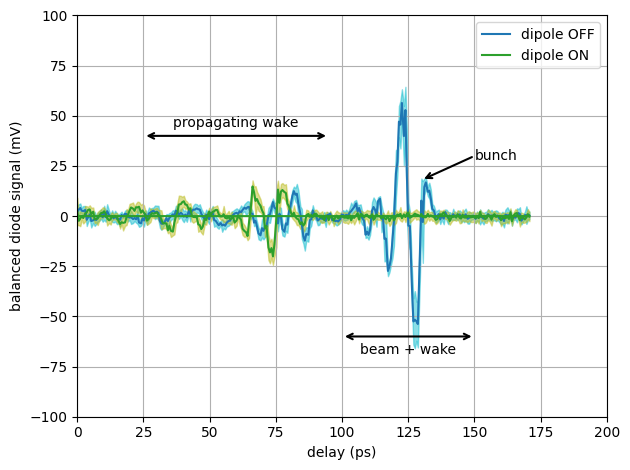

In [93]:
#plt.plot (1e3*delayOff, BPDOff-RefOff, 'C0-', label="EOModulated Off")
#plt.plot (1e3*delayOn,  BPDOn-RefOn, 'C2-', label="EOModulated Off")
atrace=BPDOff_ave-RefOff_ave
ptrace=atrace+BPDOff_std+RefOff_std
mtrace=atrace-BPDOff_std-RefOff_std
plt.plot (1e3*delayOff_ave, 1e3*atrace, 'C0', label="dipole OFF")
#plt.plot (1e3*delayOff_ave, mtrace, 'C1', label="EOModulated Off Average")
#plt.plot (1e3*delayOff_ave, ptrace, 'C3', label="EOModulated Off Average")
plt.fill_between(1e3*delayOff_ave, 1e3*mtrace, 1e3*ptrace, color='C9', alpha=0.5)
atrace=BPDOn_ave-RefOn_ave
ptrace=atrace+BPDOn_std+RefOn_std
mtrace=atrace-BPDOn_std-RefOn_std
plt.plot (1e3*delayOn_ave, 1e3*atrace, 'C2')
#plt.plot (1e3*delayOn_ave, mtrace, 'C4', label="EOModulated On Average")
plt.plot (1e3*delayOn_ave, atrace, 'C2', label="dipole ON")
plt.fill_between(1e3*delayOn_ave, 1e3*mtrace, 1e3*ptrace, color='C8', alpha=0.5)
plt.grid()
plt.legend()
plt.xlabel("delay (ps)")
plt.ylabel("balanced diode signal (mV)")
figfile=f"{dir}BPD_vs_Delay.png"
#add a double arrow to the plot from 100 to 150 in the x axis
plt.annotate('', xy=(150, -60), xytext=(100, -60),
             arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.text(125, -70, 'beam + wake', ha='center', va='bottom')
plt.annotate('', xy=(95, 40), xytext=(25, 40),
             arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.text(60, 43, 'propagating wake', ha='center', va='bottom')

#plt.title("BPD vs Delay")
# make an arrow pointing to peak at 100 ps
plt.annotate('', xy=(130, 18), xytext=(150, 30),
             arrowprops=dict(arrowstyle='->', lw=1.5))
plt.text(150, 30, 'bunch', ha='left', va='center')
plt.xlim(0, 200)
plt.ylim(-100, 100)
plt.tight_layout()
plt.savefig(figfile,format='png',dpi=300)
plt.show()

In [11]:
delayOn[1:10]

array([0.        , 0.        , 0.        , 0.        , 0.00075214,
       0.00075214, 0.00075214, 0.00075214, 0.00075214])